# Hamiltonian Structure Gallery

**Model.** This notebook compares matrix representations of TFIM, Bose-Hubbard, SSH, Hofstadter, and Haldane Hamiltonians.

**Typical uses.** Inspecting locality, basis ordering, sparsity patterns, complex hopping conventions, and selecting structured matrices for algorithm benchmarks.

**Parameters.** Each gallery entry uses a small representative system; hopping, interaction, flux, and phase parameters determine the visible matrix structure.

**Useful plots.** A shared Hamiltonian-magnitude gallery and separate phase matrices for the complex Hofstadter and Haldane models.

In [1]:
import matplotlib.pyplot as plt

from quantum_lattice_models.models import (
    bose_hubbard_chain,
    haldane_honeycomb_lattice,
    harper_hofstadter_square_lattice,
    ssh_model,
    transverse_field_ising,
)
from quantum_lattice_models.plotting import plot_hamiltonian_matrix

In [2]:
models = [
    ("TFIM", transverse_field_ising(4, j=1.0, h=0.7)),
    ("Bose-Hubbard", bose_hubbard_chain(3, hopping=0.6, interaction=1.5, max_occupancy=2)),
    ("SSH", ssh_model(6, t1=0.4, t2=1.0)),
    ("Hofstadter", harper_hofstadter_square_lattice(4, 4, flux=0.25)),
    ("Haldane", haldane_honeycomb_lattice(2, 3, t2=0.18, phi=0.5 * 3.141592653589793)),
]

print("model | matrix shape")
print("--- | ---")
for label, H in models:
    print(f"{label} | {H.shape}")

model | matrix shape
--- | ---
TFIM | (16, 16)
Bose-Hubbard | (27, 27)
SSH | (12, 12)
Hofstadter | (16, 16)
Haldane | (12, 12)


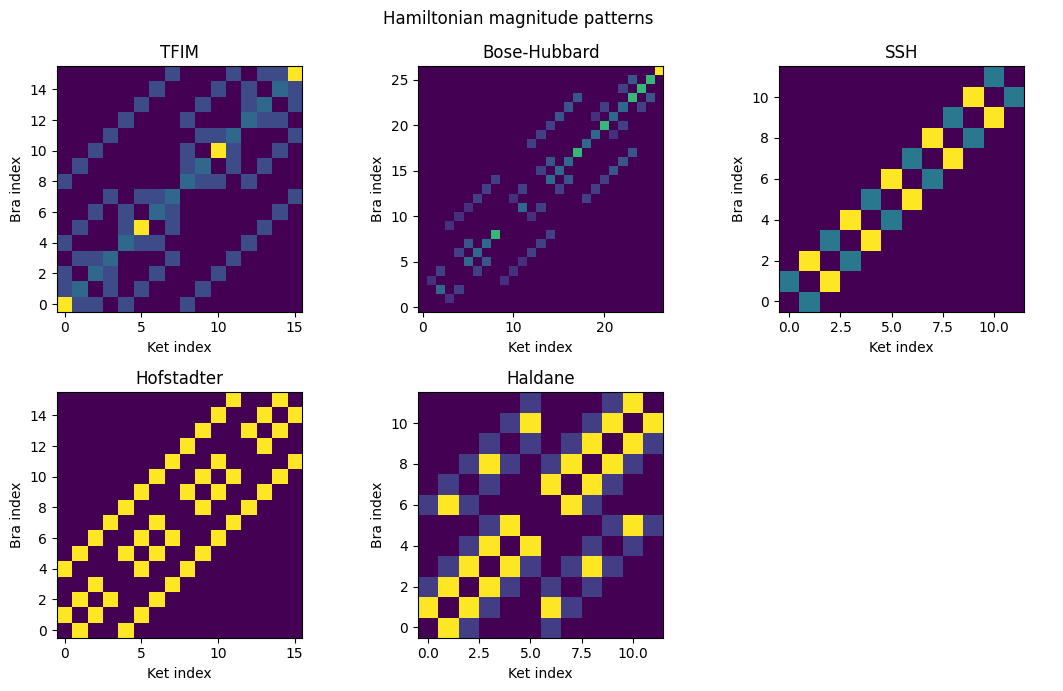

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (label, H) in zip(axes.flat, models, strict=False):
    plot_hamiltonian_matrix(H, ax=ax, mode="magnitude", show_colorbar=False)
    ax.set_title(label)
axes.flat[-1].axis("off")
fig.suptitle("Hamiltonian magnitude patterns")
fig.tight_layout()

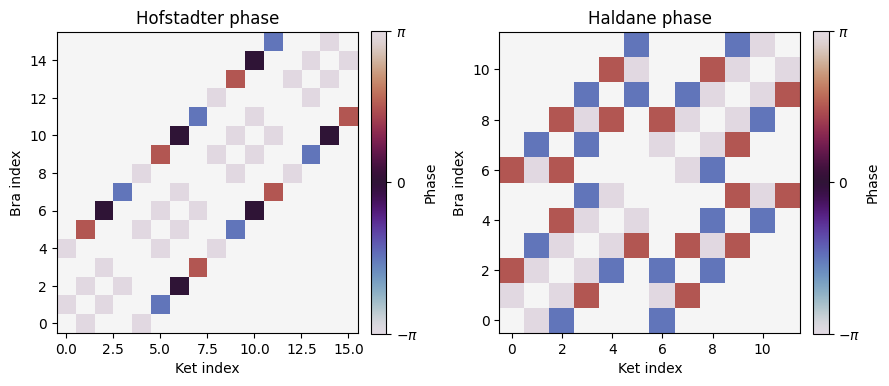

In [4]:
complex_models = [
    ("Hofstadter phase", models[3][1]),
    ("Haldane phase", models[4][1]),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (label, H) in zip(axes, complex_models, strict=True):
    plot_hamiltonian_matrix(H, ax=ax, mode="phase")
    ax.set_title(label)
fig.tight_layout()

Zero entries are masked in phase plots, so color represents only actual matrix elements. Magnitude views expose locality and basis-dependent block structure.